# Module A Report: Lightweight DBMS with B+ Tree Index

## Introduction
This notebook documents the B+ Tree implementation, benchmarking against a brute-force baseline, and Graphviz visualization outputs.

In [3]:
import os, sys
sys.path.append(os.path.abspath("database"))
from database.bplustree import BPlusTree
import pandas as pd
import matplotlib.pyplot as plt


## Implementation Details
Core methods implemented in `database/bplustree.py` include insertion, deletion with rebalance, exact search, update, range query, and visualization.

In [ ]:
tree = BPlusTree(order=4)
for key in [10, 20, 5, 6, 12, 30, 7, 17]:
    tree.insert(key, {'id': key, 'score': key * 10})

print('search(12):', tree.search(12))
print('range_query(6, 17):', tree.range_query(6, 17))
tree.delete(6)
print('after delete(6), get_all():', tree.get_all())

## Performance Analysis
Benchmark B+ Tree vs BruteForceDB for insert/search/delete/range query and memory usage.

In [ ]:
analyzer = PerformanceAnalyzer(order=16, seed=42)
results = analyzer.run(sizes=[100, 1000, 5000], searches=200, deletes=100, ranges=100)
df = pd.DataFrame(analyzer.to_rows(results))
df

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['insert_time_ms', 'search_time_ms', 'delete_time_ms', 'range_time_ms']
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    for structure in df['structure'].unique():
        sub = df[df['structure'] == structure]
        ax.plot(sub['size'], sub[metric], marker='o', label=structure)
    ax.set_title(metric)
    ax.set_xlabel('Dataset size')
    ax.set_ylabel('Time (ms)')
    ax.legend()

plt.tight_layout()
plt.show()

## Tree Visualization
Use Graphviz to render and inspect B+ Tree structure and leaf linkage.

In [4]:
import importlib
import database.bplustree as bpt_mod

# Reload module so notebook uses latest visualization fix from disk.
importlib.reload(bpt_mod)
BPlusTree = bpt_mod.BPlusTree
print('Using BPlusTree from:', bpt_mod.__file__)

Using BPlusTree from: /Users/tejasmacipad/Desktop/Multi-Course-Attendance-Management-Portal/Module-A/database/bplustree.py


Starting B+ Tree Visual Tests...

Test 1: Random Insertion
Insertion order: [23, 15, 3, 16, 5, 17, 9, 22, 11, 2, 7, 4, 12, 18, 1, 21, 13, 20, 14, 19, 0, 6, 24, 8, 10]

Inserting 23


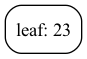


Inserting 15


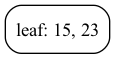


Inserting 3


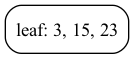


Inserting 16


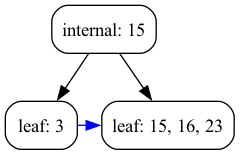


Inserting 5


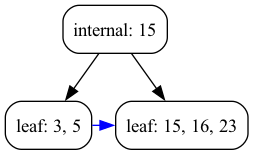


Inserting 17


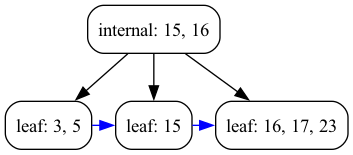


Inserting 9


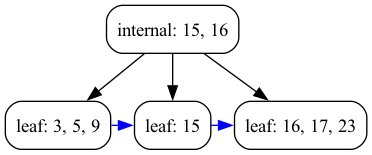


Inserting 22


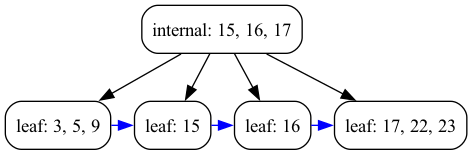


Inserting 11


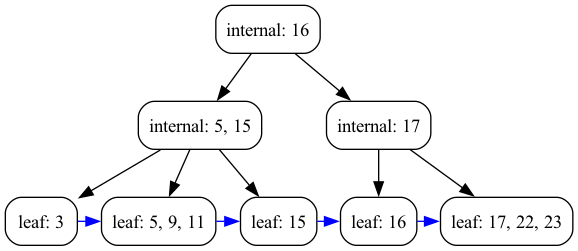


Inserting 2


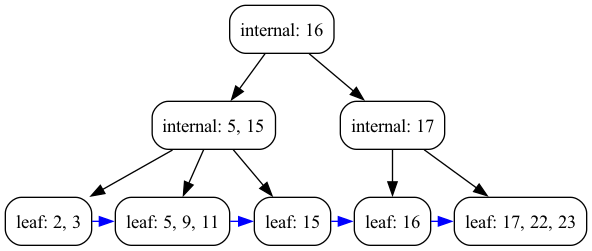


Inserting 7


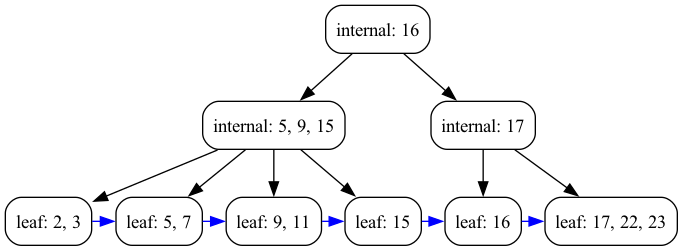


Inserting 4


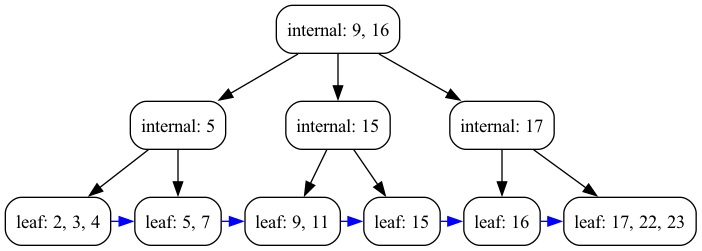


Inserting 12


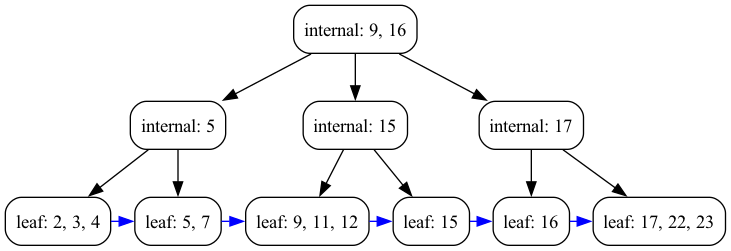


Inserting 18


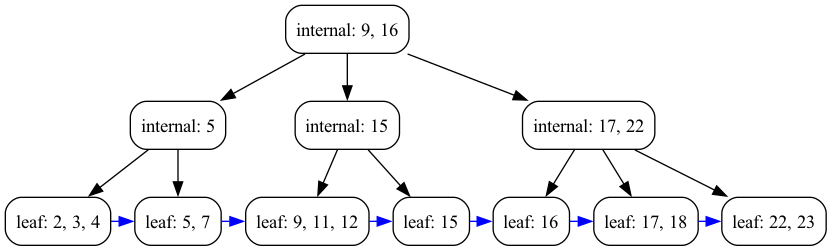


Inserting 1


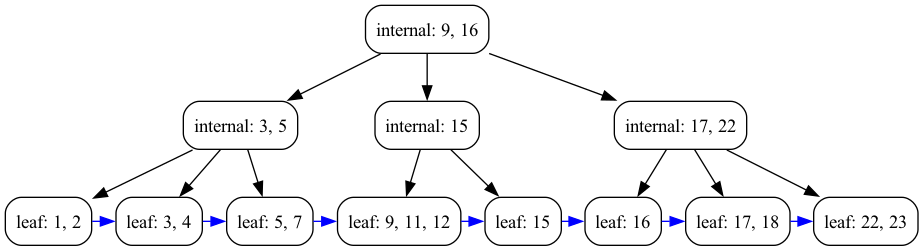


Inserting 21


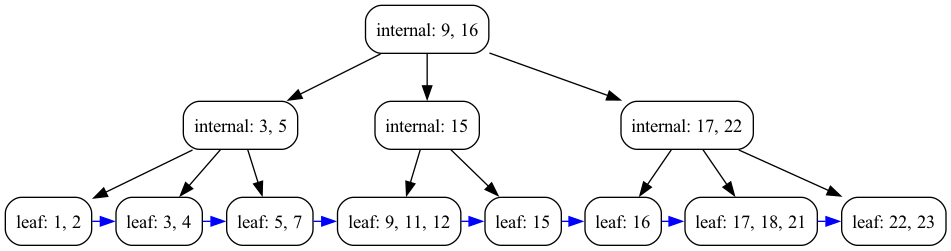


Inserting 13


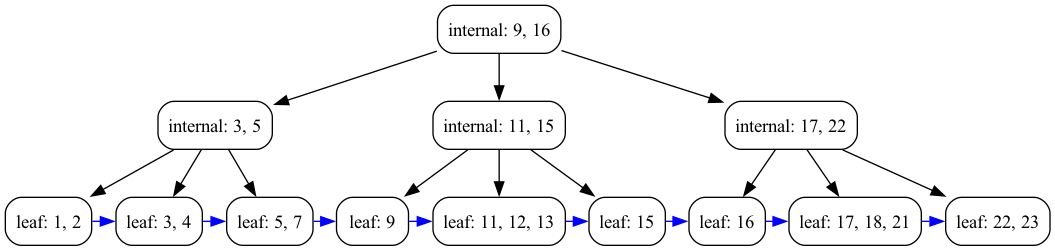


Inserting 20


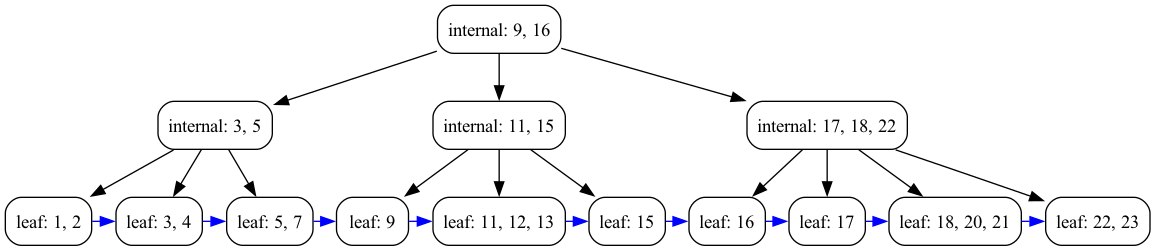


Inserting 14


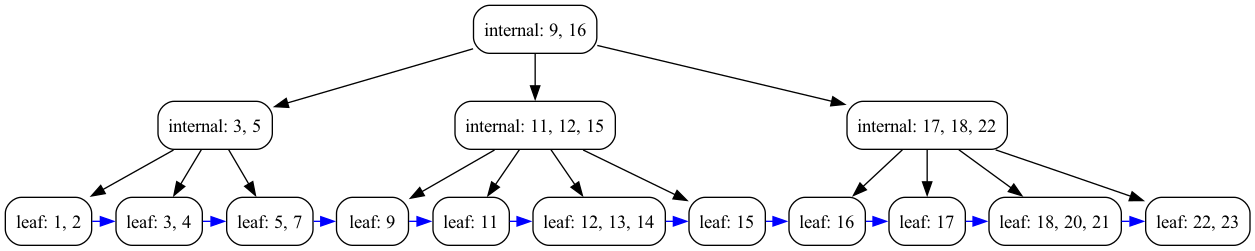


Inserting 19


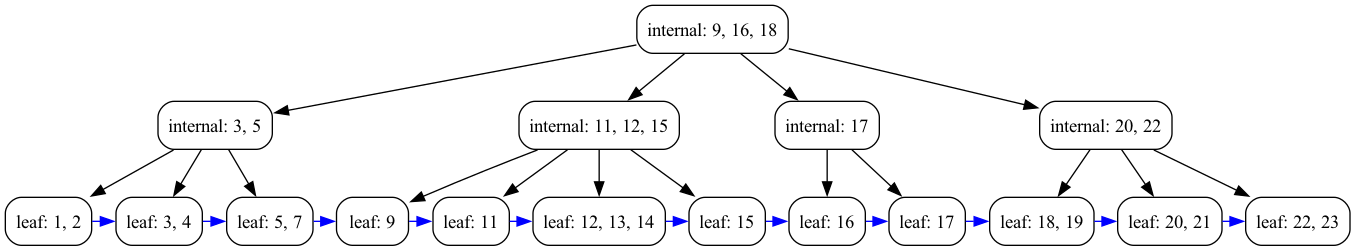


Inserting 0


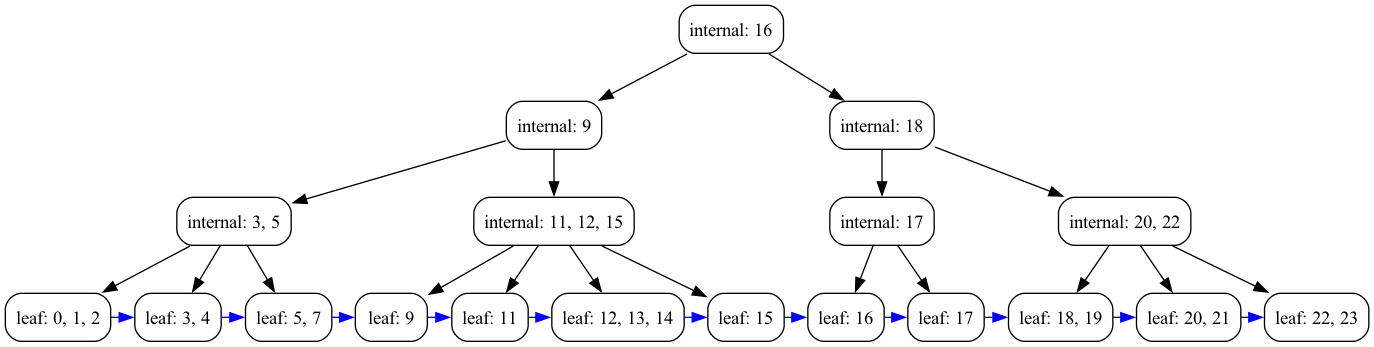


Inserting 6


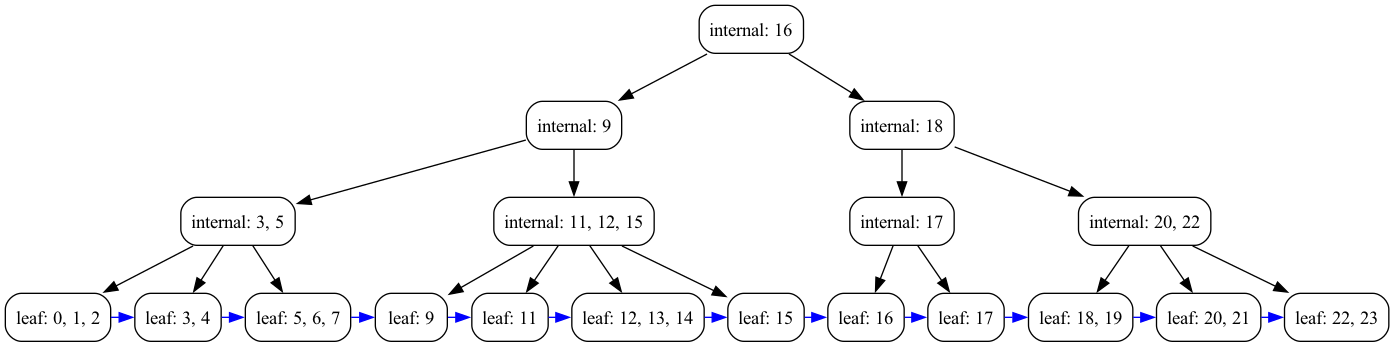


Inserting 24


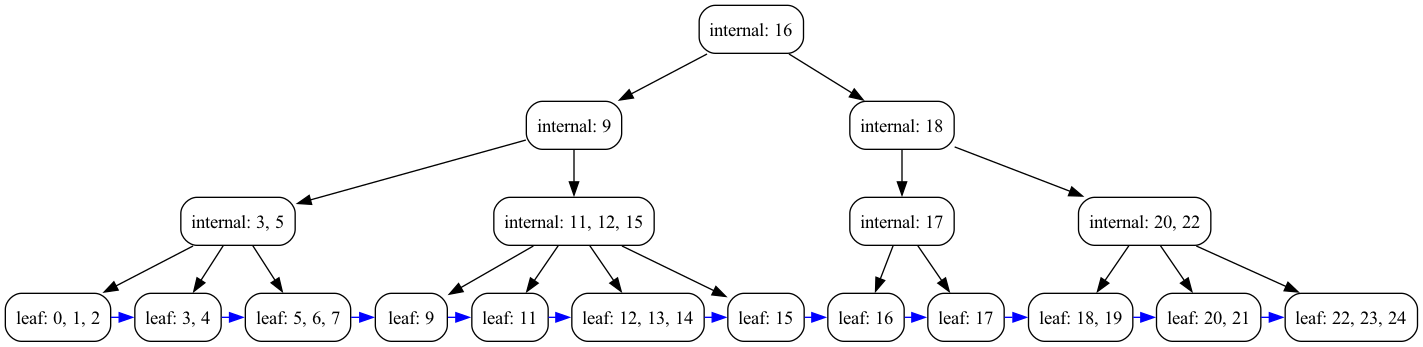


Inserting 8


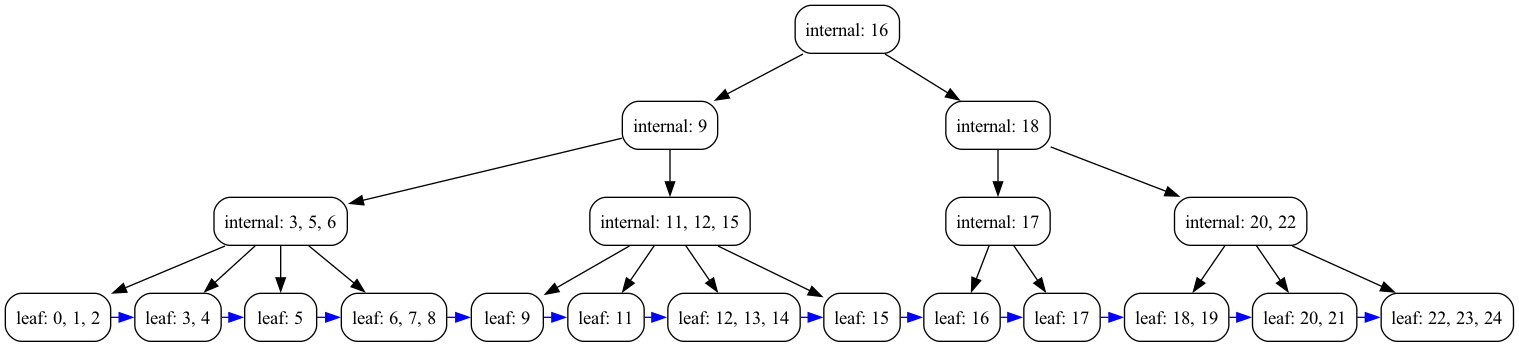


Inserting 10


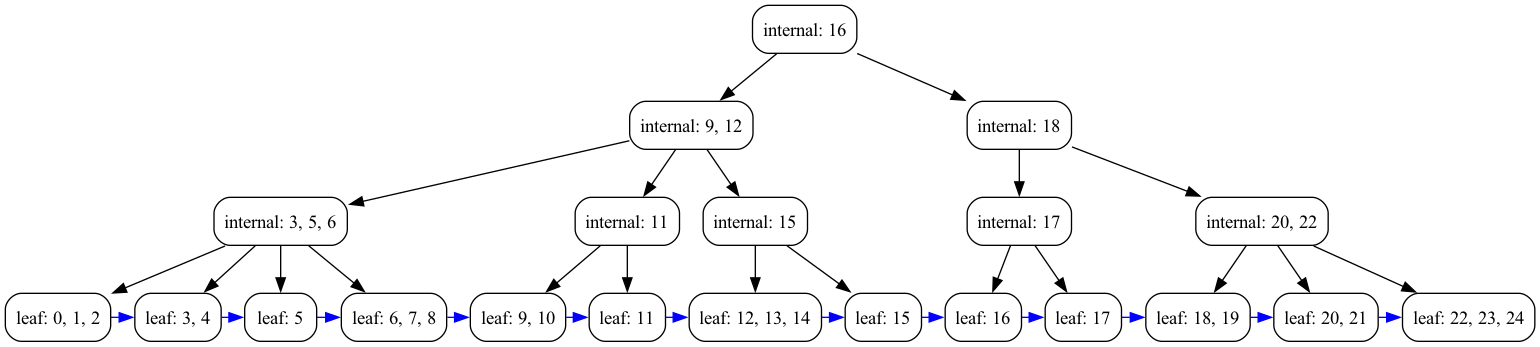


Test 2: Exact Search

Searching 6
Result: {'id': 6, 'value': 600}


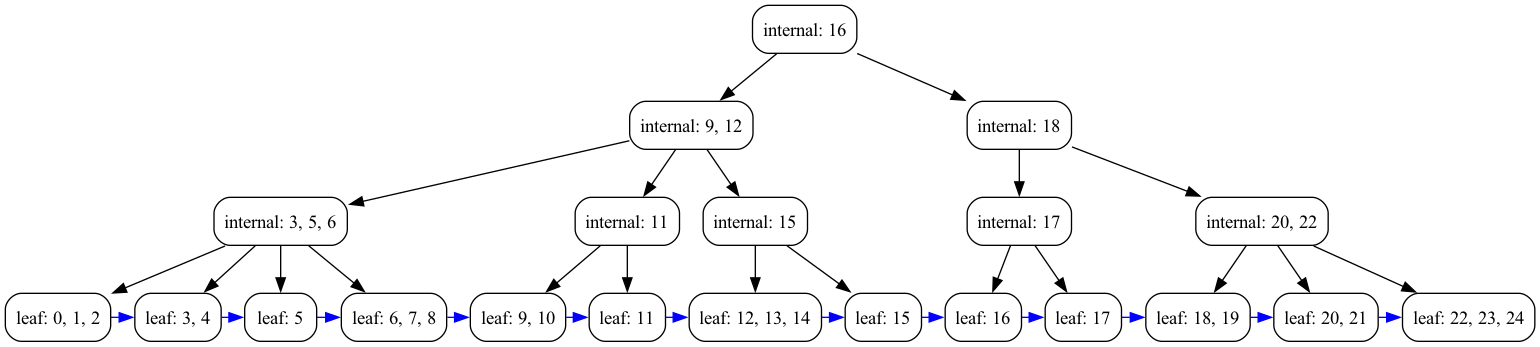


Searching 4
Result: {'id': 4, 'value': 400}


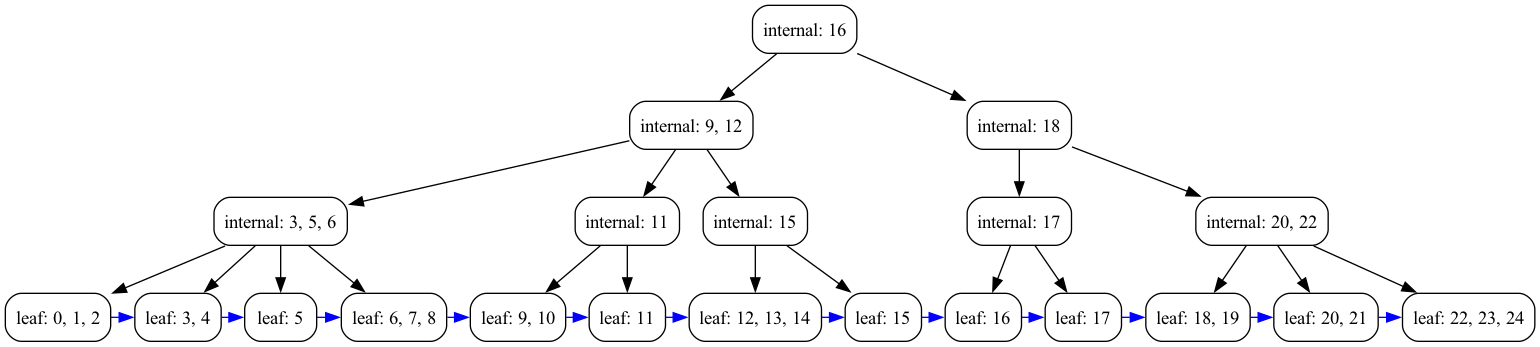


Searching 11
Result: {'id': 11, 'value': 1100}


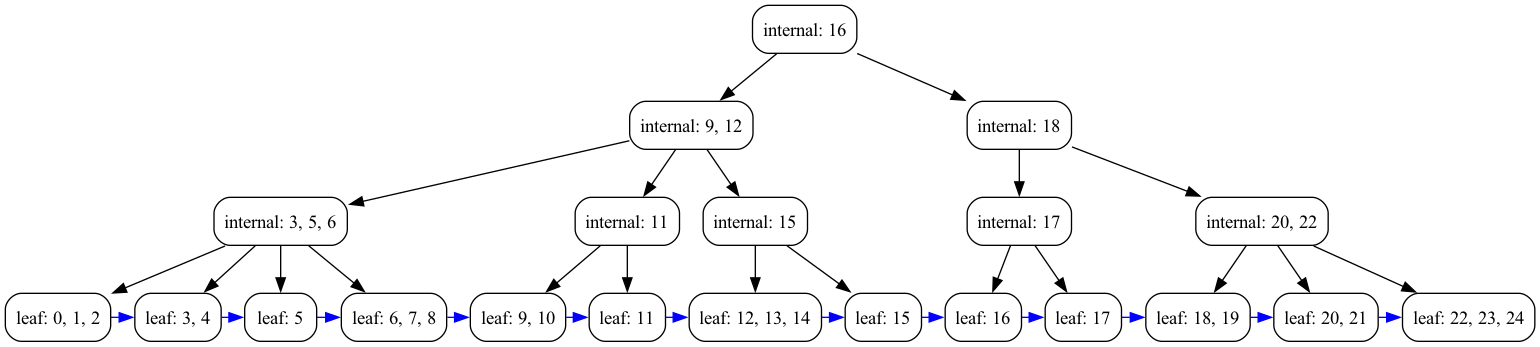


Test 3: Range Query

Range Query [9, 17]
Result: [(9, {'id': 9, 'value': 900}), (10, {'id': 10, 'value': 1000}), (11, {'id': 11, 'value': 1100}), (12, {'id': 12, 'value': 1200}), (13, {'id': 13, 'value': 1300}), (14, {'id': 14, 'value': 1400}), (15, {'id': 15, 'value': 1500}), (16, {'id': 16, 'value': 1600}), (17, {'id': 17, 'value': 1700})]


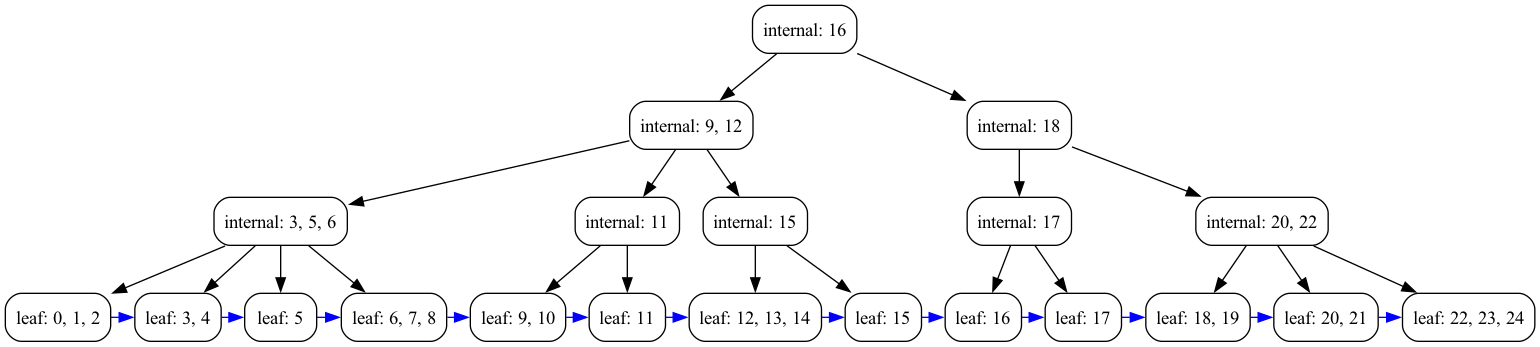


Test 4: Random Deletion
Deletion order: [17, 5, 13, 1, 11, 7, 20, 18, 12, 22, 21, 19, 15, 24, 23, 6, 10, 9, 14, 16, 8, 0, 4, 3, 2]

Deleting 17


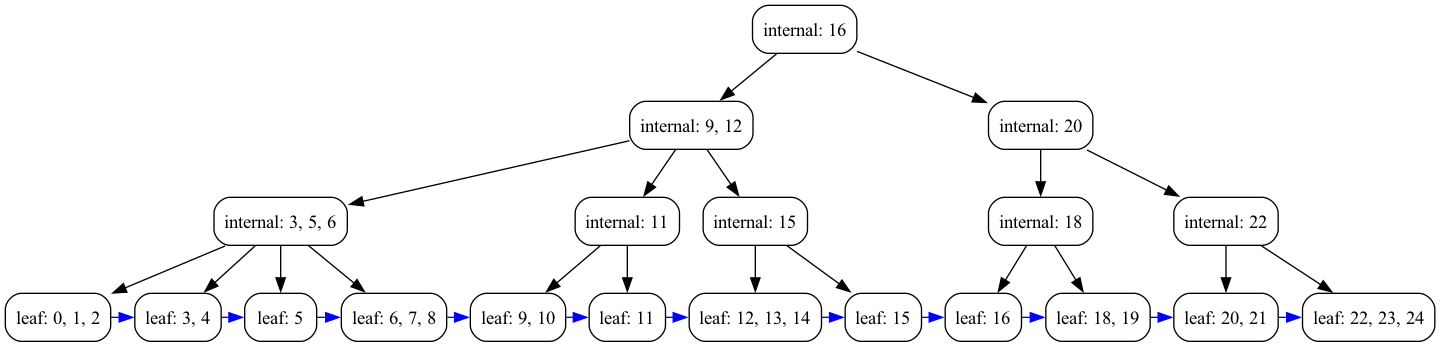


Deleting 5


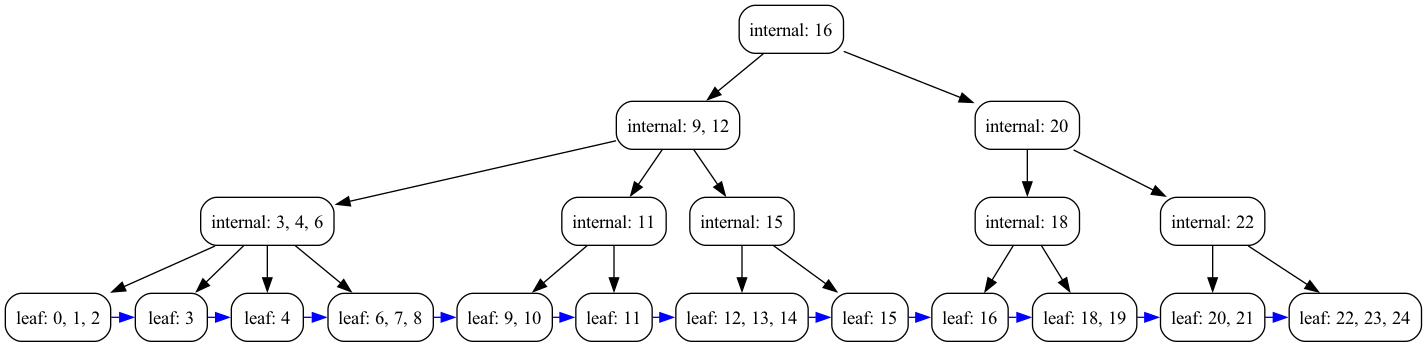


Deleting 13


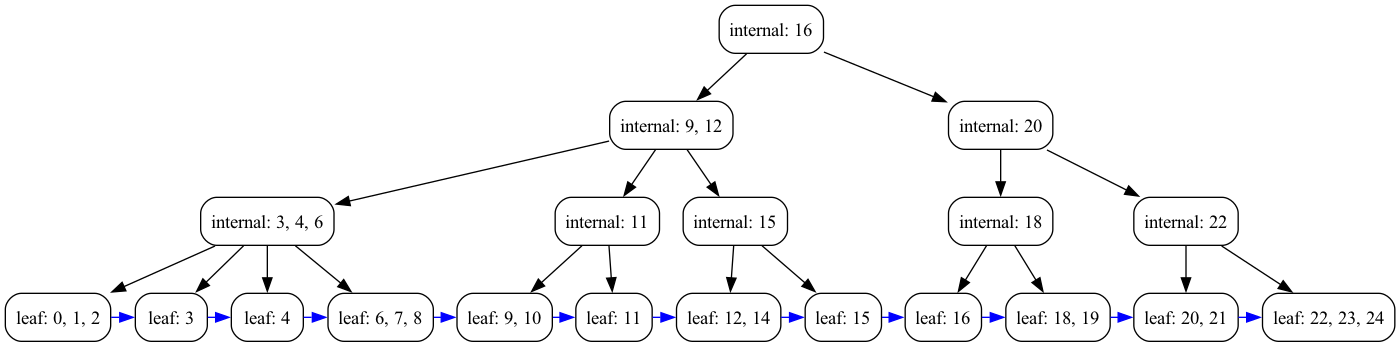


Deleting 1


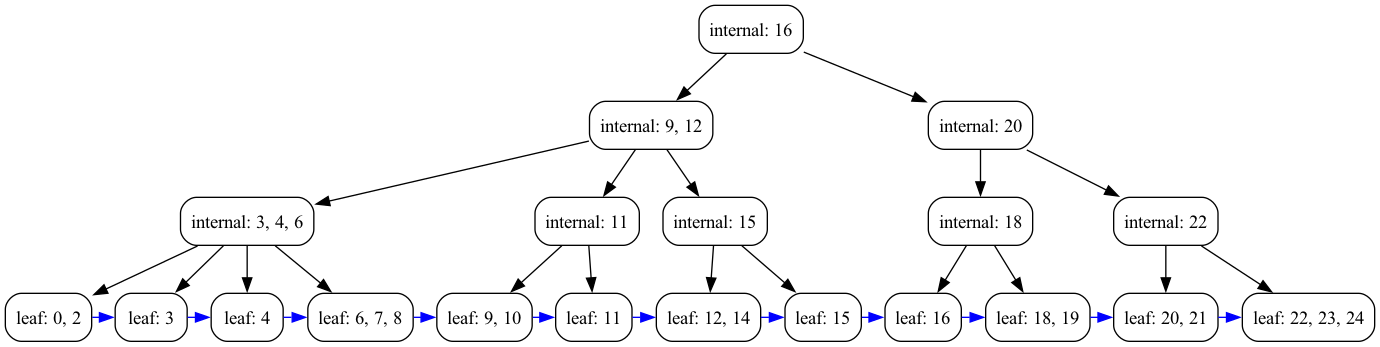


Deleting 11


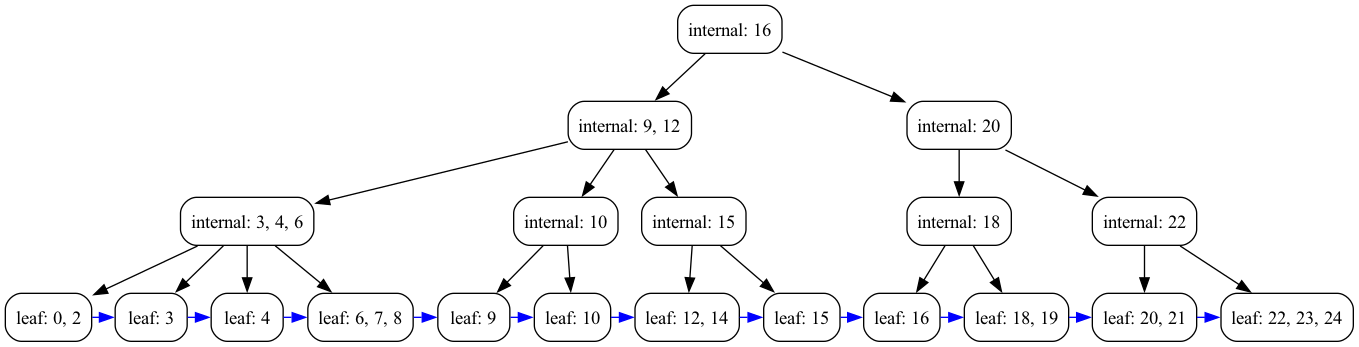


Visual Test Completed!


In [5]:
from IPython.display import Image, display
import os
import random

def show_tree(tree, step_name):
    filename = f"bplustree_{step_name}"
    images_dir = "demo_images"
    os.makedirs(images_dir, exist_ok=True)

    output_base = os.path.join(images_dir, filename)
    tree.visualize_tree(output_path=output_base, view=False)

    image_path = output_base + ".png"
    if os.path.exists(image_path):
        display(Image(filename=image_path))
    else:
        print(f"Image not generated for {step_name}")

def test_bplustree_visual():
    print("Starting B+ Tree Visual Tests...\n")

    tree = BPlusTree(order=4) # for internal node min_children=3, max_children=6, min_keys=2, max_keys=5 and leaf node min_keys=3, max_keys=6

    # -----------------------------
    # 1. RANDOM INSERTION
    # -----------------------------
    print("Test 1: Random Insertion")

    keys = list(range(25))
    random.shuffle(keys)

    print("Insertion order:", keys)

    for key in keys:
        print(f"\nInserting {key}")
        tree.insert(key, {"id": key, "value": key * 100})
        show_tree(tree, f"insert_{key}")

    # -----------------------------
    # 2. EXACT SEARCH
    # -----------------------------
    print("\nTest 2: Exact Search")

    search_keys = random.sample(keys, 3)

    for key in search_keys:
        print(f"\nSearching {key}")
        result = tree.search(key)
        print("Result:", result)
        show_tree(tree, f"search_{key}")

    # -----------------------------
    # 3. RANGE QUERY
    # -----------------------------
    print("\nTest 3: Range Query")

    l, r = sorted(random.sample(keys, 2))
    print(f"\nRange Query [{l}, {r}]")

    result = tree.range_query(l, r)
    print("Result:", result)
    show_tree(tree, f"range_{l}_{r}")

    # -----------------------------
    # 4. RANDOM DELETION
    # -----------------------------
    print("\nTest 4: Random Deletion")

    delete_keys = keys.copy()
    random.shuffle(delete_keys)

    print("Deletion order:", delete_keys)

    for key in delete_keys[:5]:  # delete some, not all
        print(f"\nDeleting {key}")
        tree.delete(key)
        show_tree(tree, f"delete_{key}")

    print("\nVisual Test Completed!")


# Run
test_bplustree_visual()